In [135]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
import mlflow


In [137]:
user_features = pd.read_csv('user_features.csv')
mlflow.set_tracking_uri('http://127.0.0.1:5001/')

X = user_features.drop(columns=["user", "label"])
y = user_features["label"]

X_test = np.load('subset_training_batch.npz')

print(X.shape, y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

neg = (y == 0).sum()
pos = (y == 1).sum()

scale_pos_weight = neg / pos
print(scale_pos_weight)

'''
1. n_estimators
    - number of trees used in ensemble
    - higher the #, bias will decrease but variance will increase
2. learning_rate
    - controls how much each tree contributes
    - higher rate, faster covergence but less stable
    - smaller learning rate --> increase # of estimators
3. max_depth 
    - controls how comlpex each tree becomes
    - depth = number of sequential splits
    - larger depth == higher overfitting
4. min_child_weight
    - Minimum number of samples required to create a leaf.
    - larger value --> harder to split --> less overfitting
5. gamma
    - Minimum loss reduction required to split.
    - Split occurs only if gain > gamma
'''

mlflow.xgboost.autolog(
    log_input_examples=True,
    log_model_signatures=True,
    log_models=True,
    log_datasets=True,
    model_format="json",  # Recommended for portability
    registered_model_name="XGBoost_User_Anomaly_Detection_Model",
    extra_tags={"team": "data-science"},
)

with mlflow.start_run(experiment_id=1, tags={'version': 'v1'}):
    model = xgb.XGBClassifier(
        n_estimators=500,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.7,# Introduce randomness to prevent overfitting(fraction of rows used per tree)
        colsample_bytree=0.8,#Fraction of features used per tree to reduce feature dominance
        scale_pos_weight=17,# Used for class imbalance, misclassifying anomolies will be heavily penalized
        random_state=42,
        eval_metric="aucpr"
    )

    model.fit(X_train, y_train)


y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)


(1100, 14) (1100,)
10.0


2026/03/15 19:13:31 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/Kathir/Documents/Coursework/machine_learning/ml_env/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/03/15 19:13:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Succes

🏃 View run amusing-sponge-434 at: http://127.0.0.1:5001/#/experiments/1/runs/1ff36a22731249dfb83f52c8dd0cd783
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1
user_min_rating        0.201942
rating_0.0_count       0.162975
user_rating_std        0.111279
user_mean_rating       0.080831
rating_3.0_count       0.064595
item_coverage          0.054881
rating_2.0_count       0.053235
rating_5.0_count       0.051053
rating_4.0_count       0.048989
rating_1.0_count       0.048242
avg_item_popularity    0.046001
num_ratings            0.039773
Unnamed: 0             0.036204
user_max_rating        0.000000
dtype: float32


In [138]:
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Normal", "Actual Anomaly"],
    columns=["Predicted Normal", "Predicted Anomaly"]
)

print("Confusion Matrix:")
print(cm_df)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
classification_report_dict = classification_report(y_test, y_pred, output_dict=True)

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

auprc = average_precision_score(y_test, y_prob)
print("AUPRC:", auprc)

Confusion Matrix:
                Predicted Normal  Predicted Anomaly
Actual Normal                199                  1
Actual Anomaly                 9                 11

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       200
           1       0.92      0.55      0.69        20

    accuracy                           0.95       220
   macro avg       0.94      0.77      0.83       220
weighted avg       0.95      0.95      0.95       220

ROC-AUC: 0.92525
AUPRC: 0.770443167943168


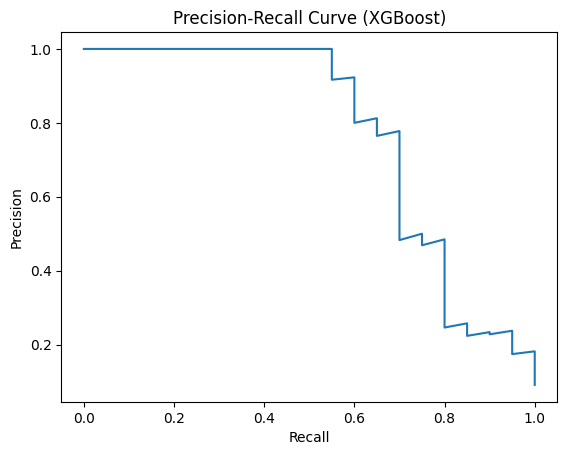

[0.09090909 0.0913242  0.09174312 0.0921659  0.09259259 0.09302326
 0.09345794 0.09389671 0.09433962 0.09478673 0.0952381  0.09569378
 0.09615385 0.09661836 0.09708738 0.09756098 0.09803922 0.09852217
 0.0990099  0.09950249 0.1        0.10050251 0.1010101  0.10152284
 0.10204082 0.1025641  0.10309278 0.10362694 0.10416667 0.10471204
 0.10526316 0.10582011 0.10638298 0.10695187 0.10752688 0.10810811
 0.10869565 0.10928962 0.10989011 0.11049724 0.11111111 0.11173184
 0.11235955 0.11299435 0.11363636 0.11428571 0.11494253 0.11560694
 0.11627907 0.11695906 0.11764706 0.1183432  0.11904762 0.11976048
 0.12048193 0.12121212 0.12195122 0.12269939 0.12345679 0.1242236
 0.125      0.12578616 0.12658228 0.12738854 0.12820513 0.12903226
 0.12987013 0.13071895 0.13157895 0.13245033 0.13333333 0.13422819
 0.13513514 0.13605442 0.1369863  0.13793103 0.13888889 0.13986014
 0.14084507 0.14184397 0.14285714 0.14388489 0.14492754 0.1459854
 0.14705882 0.14814815 0.14925373 0.15037594 0.15151515 0.152671

In [139]:
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (XGBoost)")
plt.show()
print(precision)